In [4]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn import linear_model
## https://colab.research.google.com/drive/1Bk4zPQwAfzoSHZokKUefKL1s6lqmam6S?usp=sharing#scrollTo=fsU9d3u0HdYj ##

In [5]:
# download csv from url
url = 'https://archives.nseindia.com/content/indices/ind_nifty100list.csv' # Nifty 100 stocks
nifty100 = pd.read_csv(url)
nifty100.to_csv('ind_nifty100list.csv', index=False)
symbol= pd.read_csv("ind_nifty100list.csv")  # read csv file
symbol["ticker"] = symbol["Symbol"] + ".NS"
ticker= symbol['ticker'].values.tolist() # convert to list
sd = yf.download(ticker, interval='1d')['Close'] # download data from yahoo finance
sd
df = sd

[*********************100%***********************]  100 of 100 completed


In [6]:
df

,ABB.NS,ACC.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,ATGL.NS,...,TCS.NS,TECHM.NS,TITAN.NS,TORNTPHARM.NS,ULTRACEMCO.NS,UPL.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZOMATO.NS
Date,,,,,,,,,,,,,,,,,,,,,
1995-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-15,4379.399902,2026.849976,846.099976,2540.050049,1006.450012,845.650024,445.049988,5091.799805,3196.649902,636.349976,...,3598.300049,1300.050049,3248.600098,1872.000000,8728.349609,634.650024,915.650024,236.300003,441.049988,102.949997
2023-09-18,4320.299805,2006.699951,855.099976,2502.449951,1004.950012,831.250000,436.649994,5075.149902,3206.300049,639.150024,...,3606.149902,1289.800049,3339.500000,1884.449951,8628.000000,630.099976,912.099976,236.500000,436.100006,102.150002
2023-09-20,4329.049805,1979.800049,855.200012,2470.300049,1008.950012,818.049988,428.149994,5006.299805,3214.350098,636.799988,...,3606.050049,1274.349976,3306.649902,1884.150024,8458.150391,622.500000,904.650024,231.800003,430.100006,100.000000


In [7]:
df_Nifty = yf.download("^NSEI", interval='1d')['Close'] # download data from yahoo finance


[*********************100%***********************]  1 of 1 completed


In [8]:
#plt.plot(df.index, df['ACC.NS'])
x=df_Nifty/df['ACC.NS']

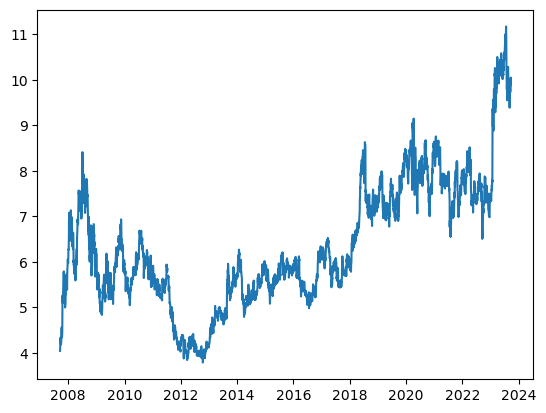

In [9]:
plt.plot(df.index, x)

In [19]:
regr = linear_model.LinearRegression()
regr.fit(df['ACC.NS'], df_Nifty)

ValueError: Expected 2D array, got 1D array instead:
array=[          nan           nan           nan ... 1979.80004883 1993.80004883
 1978.5       ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [26]:
np.reshape(df["ACC.NS"], shape, order = 'C')

NameError: name 'shape' is not defined

In [27]:
# FUNCTION TO CREATE 1D DATA INTO TIME SERIES DATASET
def new_dataset(dataset, time_steps):
    data_X, data_Y = [], []
    for i in range(len(dataset)-time_steps):
        a = dataset[i:(i+time_steps), :-1]
        data_X.append(a)
        data_Y.append(dataset[i + time_steps, -1])
    return np.array(data_X), np.array(data_Y)

In [34]:
df["ACC.NS"].reshape(-1,100,65)

AttributeError: 'Series' object has no attribute 'reshape'

In [4]:
import numpy as np

def df_to_windowed_df(Dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date
  
  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)
    
    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['ACC.NS'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
    
    if last_time:
      break
    
    target_date = next_date

    if target_date == last_date:
      last_time = True
    
  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates
  
  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]
  
  ret_df['Target'] = Y

  return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(df, 
                                '2021-03-25', 
                                '2022-03-23', 
                                n=3)
windowed_df

NameError: name 'df' is not defined